#### This notebook acts as a inspection of the 'deblend' parameter. 
It contains the code to run the source extraction using TRAP on consecutive snapshot images (specifically used for ELAISN-1 images). A Linear Regression is trained and tested to see the effect. To compare results run the notebook changing 'deblend'.

In [1]:
import os
import trap
from astropy.io import fits
from astropy.wcs import WCS
from astropy.table import Table
import astropy.units as u
from astropy.coordinates import SkyCoord
import astropy.coordinates as coord
from astropy.stats import sigma_clip
from helperfunctions import getRMS
import pandas as pd
import numpy as np
import random
import glob

In [2]:
# Settings to run trap
deblend = 0 # change to compare
radius = 2000

# Settings to run the source association
surpress_duplications = True

In [3]:
# Change:
path = '/scratch/tswinkels/build_classification_model/'
# While name stays the same, no updates to save time.
name = 'DeBlend'+str(deblend)

Cataloguepath = path+'ELAIS_catalogue.fits'
pybdsf_cols = ['Source_id', 'Total_flux', 'E_Total_flux', 'RA', 'E_RA', 'DEC', 'E_DEC', 'S_Code']
ImagePath = '/scratch/antoniar/ELAIS-N1/deep_fields_individual_epochs/*.fits'

# Create rest of paths automatically
tomlPath = path+'trap_config_'+name+'.toml'
dbpath = path+name+'_db'

## CATALOGUE

In [4]:
# Open the catalog
with fits.open(Cataloguepath) as hdul:
    # hdul.info()
    catalogue_table = Table(hdul[1].data)
    catalogue_wcs = WCS(hdul[1].header)

In [5]:
# Match to expected trap output
catalogue = catalogue_table[pybdsf_cols].to_pandas()
catalogue = catalogue.rename(columns={"RA": "ra", "E_RA": "uncertainty_ew", "DEC": "dec", "E_DEC": "uncertainty_ns"})

print(catalogue.shape)
catalogue.head()

(154952, 8)


,Source_id,Total_flux,E_Total_flux,ra,uncertainty_ew,dec,uncertainty_ns,S_Code
0,0,0.000600,0.000146,247.727729,0.000139,54.923692,0.000210,S
1,1,0.000334,0.000147,247.709353,0.000158,54.771236,0.000390,S
2,2,0.001459,0.000154,247.704080,0.000099,54.776155,0.000044,S
3,3,0.000683,0.000238,247.715686,0.000394,54.858897,0.000186,S
4,4,0.001655,0.000114,247.695477,0.000042,54.710662,0.000036,S


## TRAP SOURCES

This section runs trap to extract candidates from the images. \
https://git.astron.nl/RD/trap

In [6]:
def make_toml(tomlPath, dbpath, deblend):
    """Creates a toml file with current setting that can be used for trap"""
    with open(tomlPath, "w") as f:
        f.write(
        '''
        # This file defines the parameters to use for TraP processing
        # These parameters can be overwritten by environment variables
        # or command line arguments where command line arguments are
        # considered first, then environment variables and lastly the
        # parameters set in this file.
        
        # For an explenation of each of the parameters, run `trap-run --help` or refer to
        # the documentation at: https://transients-pipeline.readthedocs.io/en/latest/input_parameters.html
        
        [general]
        log_dir = "./logs"
        
        [database]
        db_name = "%s"
        db_backend = "sqlite"
        db_host = "localhost"
        db_port = "5432"
        db_user = "trap_test"
        db_password = "trap_test"
        db_overwrite = false
        
        [image_quality]
        rms_min = 0
        rms_max = 10
        reduction_factor_for_rms = 20
        
        [extraction]
        ew_sys_err = 0
        ns_sys_err = 0
        detection_threshold = 8
        analysis_threshold = 3
        deblend_nthresh = %s
        max_nr_consecutive_force_fits = 10
        force_beam = true
        
        [extraction.image]
        im_margin = 0
        im_radius = %s
        im_back_size_x = 50
        im_back_size_y = 50
        
        [association]
        de_ruiter_r_max = 5.68
        
        ''' % (dbpath, str(deblend), str(radius)))

In [7]:
# Run trap
if not os.path.exists(dbpath):
    make_toml(tomlPath, dbpath, deblend)
    os.system("trap-run --config_file "+tomlPath+" -i '"+ImagePath+"' --nr_threads 4")

In [8]:
# Open the database
db_handle = trap.io.open_db("sqlite", dbpath)
with db_handle.connect() as conn:
    sources = pd.read_sql_query("SELECT * FROM extracted_sources", conn)
    tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)

# Filter candidates
clean_sources = sources.groupby('src_id').filter(lambda item: not (item['is_duplicate'] == 1).any())
id_sources = clean_sources.groupby(['src_id']).first()

print(tables)

2026-02-05 13:05:20,978 - TraP - INFO - Establishing sqlite database connection for '/scratch/tswinkels/build_classification_model/DeBlend0_db' (io.py:296)
                name
0             config
1             images
2  extracted_sources


In [9]:
# Remove the toml-file
if os.path.exists(tomlPath):
    os.remove(tomlPath)

## ASSOCIATION

This method makes use of the source association of trap to associate the catalog with the found sources:\
https://git.astron.nl/RD/trap

In [10]:
from helperfunctions.associate import associate
"""
input:
sources,new_sources
output:
null_detection_ids: the ids corresponding to `new_sources.index` that were not found in sources
new_source_ids: the ids corresponding to `sources.index` that were in new_sources but not in the original sources
persistings_mapping: :class:`pd.DataFrame`: A dataframe containing the columns `[original_id, new_id, de_ruiter]` that map the indices
    from sources to new_sources of those that are identified as being a persistant source, 
    meaning it is a source that occurs in both sourcse lists.
duplicate_mapping: A dataframe containing the columns `[original_id, new_id, de_ruiter]` that map the indices 
    of any access sources in new_sources to the nearest source in the original sources DataFrame.
"""
null_detection_ids, new_source_ids, persistings_mapping, duplicate_mapping = associate(catalogue, id_sources, surpress_duplications=False)

In [11]:
# Create two dataframes that contain same sources per index
matched_catalogue = catalogue.loc[persistings_mapping['original_id'].values].reset_index(drop=True)
matched_sources = id_sources.loc[persistings_mapping['new_id'].values].reset_index()
print(matched_sources.head())

   src_id  id          ra        dec  ra_fit_err  dec_fit_err  peak_flux  \
0       0   0  244.196031  55.025001    0.000152     0.000087   0.000902   
1       1   1  244.190511  55.042292    0.000040     0.000023   0.006322   
2       3   3  244.174846  54.938558    0.000109     0.000062   0.001777   
3       4   4  244.176137  54.973847    0.000094     0.000054   0.002390   
4       5   5  244.167025  54.900110    0.000179     0.000103   0.000806   

   peak_flux_err  int_flux  int_flux_err  ...  reduced_chisq  ns_sys_err  \
0       0.000070  0.000902      0.000131  ...       6.663707         0.0   
1       0.000070  0.006322      0.000217  ...   10903.094727         0.0   
2       0.000082  0.001777      0.000177  ...      17.334593         0.0   
3       0.000089  0.002390      0.000203  ...       5.683568         0.0   
4       0.000082  0.000806      0.000143  ...      20.714401         0.0   

   ew_sys_err  gaussian_fit  uncertainty_ew  uncertainty_ns  im_id  \
0         0.0   

In [12]:
# Remove sources labeld other then S or M
if len(pd.unique(matched_catalogue.get('S_Code', ''))) > 2:
    mask = matched_catalogue.get('S_Code', '').isin(['S','M'])
    matched_catalogue = matched_catalogue[mask]
    matched_sources = matched_sources[mask]

print(matched_catalogue['S_Code'].value_counts())

S_Code
S    1066
M     590
Name: count, dtype: int64


In [13]:
import matplotlib.pyplot as plt

# Functions to visualise if the source association worked
def scatter_catalogue(ax, catalogue, wcs, size, color, title, label):
    ax.set_title(title)
    ax.set_xlabel("RA")
    ax.set_ylabel("Dec")
    ax.set_xlim((241,242))
    ax.set_ylim((54,54.5))
    
    x, y = wcs.world_to_pixel_values(catalogue['ra'],catalogue['dec'])
    ax.scatter(
        x, y,
        s=size,
        c=color,
        alpha=0.6,
        label=label)

def draw_match_lines(ax, cat1, cat2, wcs, color="gray", alpha=0.3, lw=0.7):
    x1, y1 = wcs.world_to_pixel_values(cat1['ra'], cat1['dec'])
    x2, y2 = wcs.world_to_pixel_values(cat2['ra'], cat2['dec'])
    
    for i in range(len(cat1)):
        inside1 = 242 <= x1[i] <= 243 and 54.90 <= y1[i] <= 55.10
        inside2 = 242 <= x2[i] <= 243 and 54.90 <= y2[i] <= 55.10
        
        if inside1 or inside2:
            ax.plot(
                [x1[i], x2[i]],
                [y1[i], y2[i]],
                color=color,
                alpha=alpha,
                linewidth=lw
            )

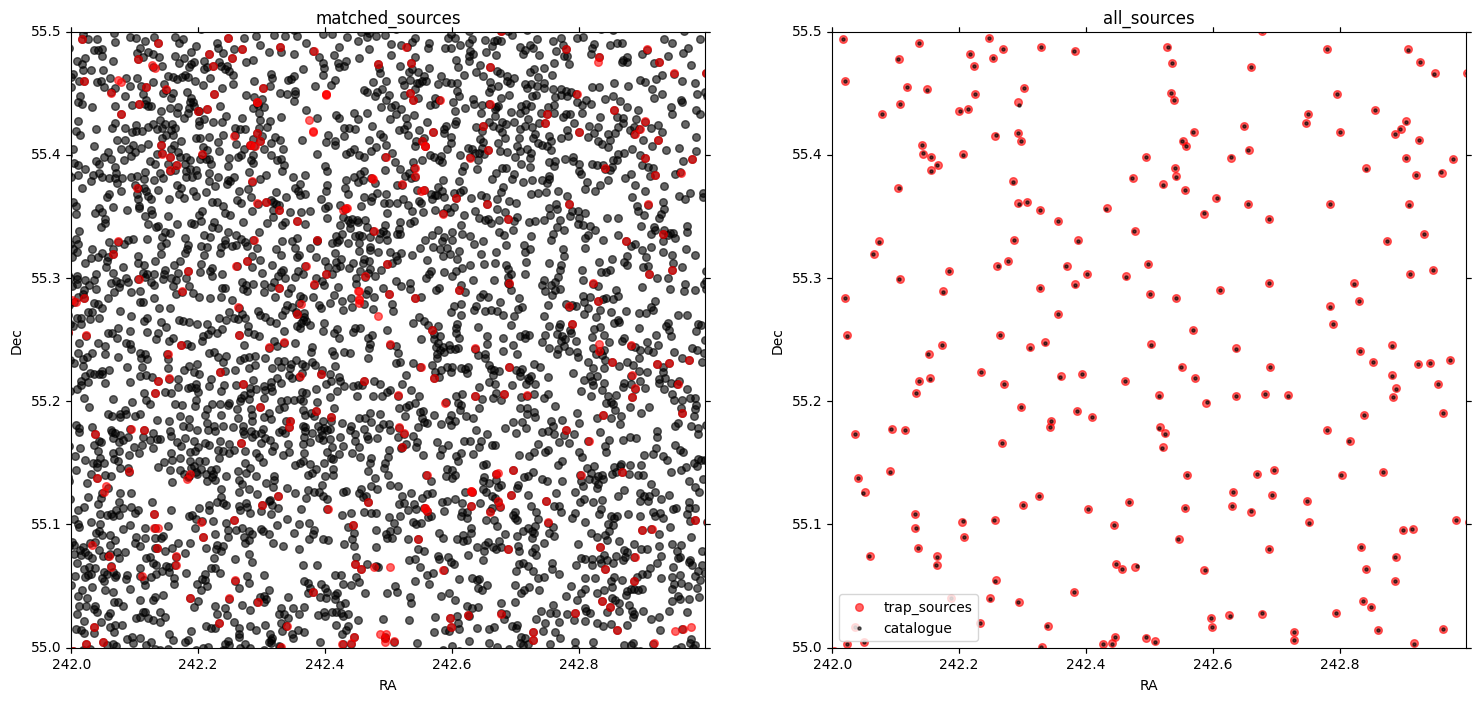

In [14]:
# Visual inspection of the source association

fig, axes = plt.subplots(1, 2, figsize=(18, 8), subplot_kw={'projection': catalogue_wcs}) 

scatter_catalogue(axes[0], catalogue, catalogue_wcs, 30, "k", "all_sources", "catalogue") 
scatter_catalogue(axes[0], id_sources, catalogue_wcs, 30, "r", "matched_sources", "trap_sources" ) 

scatter_catalogue(axes[1], matched_sources, catalogue_wcs, 30, "r", "matched_sources", "trap_sources" ) 
scatter_catalogue(axes[1], matched_catalogue, catalogue_wcs, 5, "k", "all_sources", "catalogue") 

draw_match_lines(axes[1], matched_catalogue, matched_sources, catalogue_wcs)

plt.legend()
plt.show()

## CREATE MODEL

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Some parameters for the model:
decision_boundaries = (matched_catalogue['S_Code'].value_counts(normalize=True)[0], matched_catalogue['S_Code'].value_counts(normalize=True)[1])
class_weight = {'M': 1, 'S': 1}

2026-02-05 13:05:49,236 - TraP - WARNING - FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]` (/tmp/ipykernel_63694/4017601958.py:6) (log.py:19)
2026-02-05 13:05:49,238 - TraP - WARNING - FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]` (/tmp/ipykernel_63694/4017601958.py:6) (log.py:19)


In [16]:
# Clean and split the data
X = matched_sources.copy()
X = X.drop(columns=["ra", "uncertainty_ew", "dec", "uncertainty_ns", "src_id", "id", "parent", "im_id"])
X_train, X_test, y_train, y_test = train_test_split(X, matched_catalogue['S_Code'], test_size=0.2, random_state=42)

# Define a scalar
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)
X_test_scaled.head()

,ra_fit_err,dec_fit_err,peak_flux,peak_flux_err,int_flux,int_flux_err,significance_detection_level,semimajor_axis,semiminor_axis,parallactic_angle,error_radius,chisq,reduced_chisq,ns_sys_err,ew_sys_err,gaussian_fit,is_force_fit,is_duplicate
1485,0.678504,0.753048,-0.318825,0.157227,-0.318825,-0.271506,-0.330526,-0.857916,1.498653,-0.345908,0.752586,-0.062114,-0.087501,0.0,0.0,0.0,0.0,0.0
420,-1.179280,-1.210700,0.761897,3.159410,0.761897,2.514567,9.046395,-0.972063,0.897600,0.092502,-1.214953,14.793810,6.948344,0.0,0.0,0.0,0.0,0.0
848,-0.365909,-0.382744,-0.100889,-0.006837,-0.100889,0.030713,-0.124667,1.272761,-0.745326,-1.526272,-0.382352,-0.061961,-0.084782,0.0,0.0,0.0,0.0,0.0
497,-0.078226,-0.092312,-0.150469,0.246701,-0.150469,0.061114,0.855910,-0.972063,-0.845507,-0.111605,-0.092548,0.093962,0.269657,0.0,0.0,0.0,0.0,0.0
1390,0.591191,0.620028,-0.342985,-0.447432,-0.342985,-0.548553,-0.311671,-0.096946,-0.585038,-0.953413,0.619838,-0.062139,-0.088298,0.0,0.0,0.0,0.0,0.0


In [17]:
# Define and train the model
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight=class_weight)
log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,"{'M': 1, 'S': 1}"
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [18]:
# Function to classify the output with specified boundaries
def classify(row):
        p = row.Prob_M
        # pred = row.Predicted_Label
        if p >= decision_boundaries[0]: # and pred == "M":
            return "Confident M"
        elif p <= decision_boundaries[1]: # and pred == "S":
            return "Confident S"
        else:
            return "Uncertain"

In [19]:
# Gather all results
prob_M = log_reg.predict_proba(X_test_scaled)[:, list(log_reg.classes_).index('M')]
results = pd.DataFrame({
    "Prob_M": prob_M,
    "Predicted_Label": log_reg.predict(X_test_scaled),
    "True_Label": y_test.values},
    index=X_test.index)

results["Decision"] = results.apply(classify, axis=1)
results.head()

,Prob_M,Predicted_Label,True_Label,Decision
1485,0.345921,S,S,Confident S
420,0.831563,M,M,Confident M
848,0.370970,S,S,Uncertain
497,0.512499,M,M,Uncertain
1390,0.330023,S,S,Confident S



--- Decision Distribution ---
Decision
Confident S    225
Uncertain       94
Confident M     13
Name: count, dtype: int64 

Confident M: 13 samples | accuracy: 0.77
Confident S: 225 samples | accuracy: 0.69
Uncertain: 94 samples | accuracy: 0.59


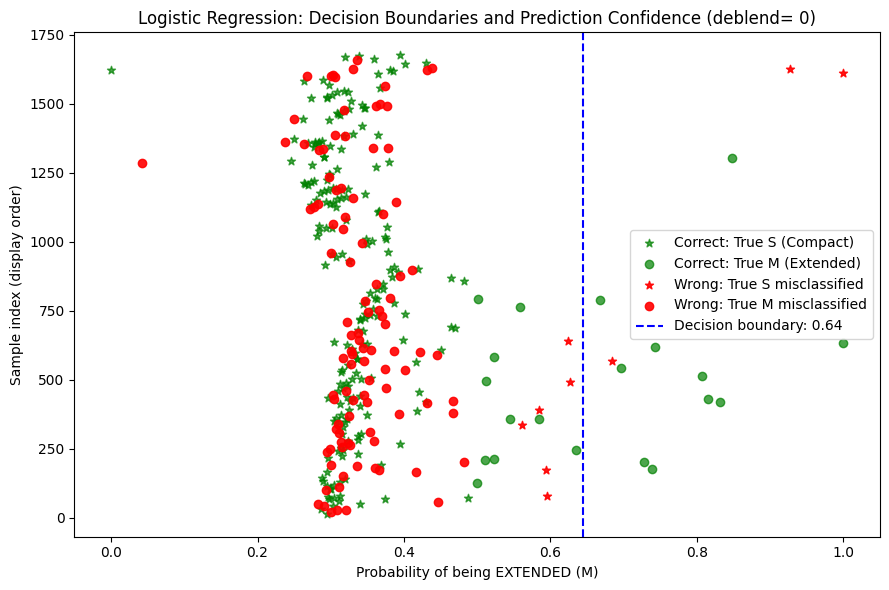

In [20]:
# Quantify the model performance
print("\n--- Decision Distribution ---")
print(results["Decision"].value_counts(), "\n")

for group in ["Confident M", "Confident S", "Uncertain"]:
    subset = results[results["Decision"] == group]
    if len(subset) > 0:
        acc = (subset["True_Label"] == subset["Predicted_Label"]).mean()
    else:
        acc = 0
    print(f"{group}: {len(subset)} samples | accuracy: {acc:.2f}")

# Split correct and incorrect predictions
correct = results[results["True_Label"] == results["Predicted_Label"]]
correct_s = correct[correct["True_Label"] == 'S']  # true single-point
correct_m = correct[correct["True_Label"] == 'M']  # true extended

wrong = results[results["True_Label"] != results["Predicted_Label"]]
wrong_true_s = wrong[wrong["True_Label"] == 'S']
wrong_true_m = wrong[wrong["True_Label"] == 'M']

# Plot a visualisation of the performance of the model
plt.figure(figsize=(9, 6))

# Plot correct first
plt.scatter(correct_s['Prob_M'], correct_s.index, c="green", marker='*', alpha=0.7,
            label="Correct: True S (Compact)")
plt.scatter(correct_m['Prob_M'], correct_m.index, c="green", alpha=0.7,
            label="Correct: True M (Extended)")

# Wrong on top
plt.scatter(wrong_true_s['Prob_M'], wrong_true_s.index, c="red", marker='*', alpha=0.9,
            label="Wrong: True S misclassified")
plt.scatter(wrong_true_m['Prob_M'], wrong_true_m.index, c="red", alpha=0.9,
            label="Wrong: True M misclassified")

# Decision boundaries
plt.axvline(decision_boundaries[0], linestyle="--", color='blue', label=f"Decision boundary: {np.round(decision_boundaries[0],2)}")

plt.xlabel("Probability of being EXTENDED (M)")
plt.ylabel("Sample index (display order)")
plt.title(f"Logistic Regression: Decision Boundaries and Prediction Confidence (deblend= {deblend})")
plt.legend()
plt.tight_layout()
plt.show()
